# Developer Guide: Extending ggplot2_py

This notebook is the **Python equivalent of R's `vignettes/extending-ggplot2.qmd`**.
It covers every extension mechanism available in ggplot2_py, from creating custom
Stats and Geoms to registering entirely new component types via singledispatch.

## Architecture overview

ggplot2_py implements the **Grammar of Graphics** (GOG) as 7 independently extensible
components plus a theming system:

| Component | Base class | Responsibility |
|-----------|-----------|----------------|
| **Data** | `pd.DataFrame` | Input observations |
| **Aesthetics** | `Mapping` | Map data columns to visual properties |
| **Geom** | `Geom` | Render data as visual marks (points, lines, etc.) |
| **Stat** | `Stat` | Compute statistical summaries before rendering |
| **Scale** | `Scale` | Mediate between data space and aesthetic space |
| **Coord** | `Coord` | Transform positions into viewport coordinates |
| **Facet** | `Facet` | Split data into panels |
| **Theme** | `theme()` | Control non-data visual elements |

Each component is independently extensible. Extension authors subclass the base class,
and the `__init_subclass__` hook auto-registers the new class so it can be referenced
by name (e.g. `geom="star"` resolves to `GeomStar`).

### Python-exclusive features (no R equivalent)

- **`typing.Protocol` contracts** --- structural typing for compile-time and runtime validation
- **`singledispatch` extensibility** --- register any Python class with the `+` operator
- **Build hooks** --- intercept data at any of 16 named pipeline stages
- **Callable `aes()` expressions** --- lambdas instead of R's non-standard evaluation
- **`ggplot_defaults()` context manager** --- scoped defaults without global side effects

In [1]:
%matplotlib agg

In [2]:
import numpy as np
import pandas as pd

np.random.seed(42)
df = pd.DataFrame({
    'x': np.random.uniform(1.5, 7, 50),
    'y': np.random.normal(25, 5, 50),
    'class': np.random.choice(['compact', 'suv', 'midsize'], 50),
})
df.head()

,x,y,class
0,3.559971,28.692333,suv
1,6.728929,25.856841,suv
2,5.525967,24.421759,midsize
3,4.792622,23.494482,suv
4,2.358103,17.607390,midsize


In [3]:
from ggplot2_py import BuildStage

# The 16 named pipeline stages, in execution order
stages = [
    BuildStage.LAYER_DATA,
    BuildStage.SETUP_LAYER,
    BuildStage.SETUP_LAYOUT,
    BuildStage.COMPUTE_AESTHETICS,
    BuildStage.TRANSFORM_SCALES,
    BuildStage.TRAIN_POSITION,
    BuildStage.COMPUTE_STAT,
    BuildStage.MAP_STAT,
    BuildStage.COMPUTE_GEOM_1,
    BuildStage.COMPUTE_POSITION,
    BuildStage.RETRAIN_POSITION,
    BuildStage.SETUP_GUIDES,
    BuildStage.TRAIN_NONPOSITION,
    BuildStage.COMPUTE_GEOM_2,
    BuildStage.FINISH_STAT,
    BuildStage.FINISH_DATA,
]

print("ggplot_build pipeline stages:")
for i, s in enumerate(stages, 1):
    print(f"  {i:2d}. {s}")

ggplot_build pipeline stages:
   1. layer_data
   2. setup_layer
   3. setup_layout
   4. compute_aesthetics
   5. transform_scales
   6. train_position
   7. compute_stat
   8. map_stat
   9. compute_geom_1
  10. compute_position
  11. retrain_position
  12. setup_guides
  13. train_nonposition
  14. compute_geom_2
  15. finish_stat
  16. finish_data


---

## Section 2: The ggproto System

R's ggplot2 uses a prototype-based OOP system called **ggproto**. Classes act as both
types *and* singletons --- `GeomPoint` is simultaneously a class and a usable object.
The Python port preserves this duality through `GGProtoMeta`, a metaclass that makes
class-level attribute access work like instance-level access.

Key pieces:

| Symbol | Role |
|--------|------|
| `GGProtoMeta` | Metaclass enabling class-as-singleton semantics |
| `GGProto` | Base class for all GOG components |
| `ggproto(name, parent, **members)` | Factory that creates a new class dynamically (mirrors R's `ggproto()`) |
| `ggproto_parent(Parent, self)` | Returns a proxy for calling parent-class methods (like R's `ggproto_parent()`) |

Functions whose first parameter is named `self` are **auto-bound** when accessed
on instances --- so `MyProto().greet()` works with auto-bound `self`.

In [4]:
from ggplot2_py.ggproto import GGProto, ggproto, ggproto_parent, is_ggproto

# ggproto() creates a new class dynamically --- mirrors R's ggproto()
MyProto = ggproto(
    "MyProto", GGProto,
    value=42,
    greet=lambda self: f"Hello, value={self.value}",
)
print(repr(MyProto))                  # class repr
print(MyProto().greet())              # auto-bound method call on an instance
print("is_ggproto:", is_ggproto(MyProto))

<ggproto class: MyProto>
Hello, value=42
is_ggproto: True


In [5]:
# Inheritance: Child inherits greet() but overrides value
Child = ggproto("Child", MyProto, value=99)
print(Child().greet())  # "Hello, value=99" --- inherited method, overridden attribute

# ggproto_parent() for explicit super-call dispatch
Grandchild = ggproto(
    "Grandchild", Child,
    value=1,
    greet=lambda self: f"GC says: {ggproto_parent(Child, self).greet()} (original)",
)
print(Grandchild().greet())

Hello, value=99
GC says: Hello, value=1 (original)


In [6]:
# Instance-level override (prototype semantics)
obj = MyProto()
obj._set(value=0)
print("Instance greet:", obj.greet())    # uses instance-level value=0
print("Class greet:", MyProto().greet())  # class still has value=42

Instance greet: Hello, value=0
Class greet: Hello, value=42


---

## Section 3: Creating a Custom Stat

Stats transform data before the Geom renders it. The lifecycle is:

```
setup_params(data, params) -> params
  setup_data(data, params) -> data
    compute_layer(data, params, layout) -> data
      compute_panel(data, scales, **params) -> data    [per-panel]
        compute_group(data, scales, **params) -> data  [per-group]
    finish_layer(data, params) -> data
```

Most custom stats only need to override `compute_group()`.

### Key class attributes

| Attribute | Type | Purpose |
|-----------|------|---------|
| `required_aes` | `list[str]` | Aesthetics that *must* be present |
| `non_missing_aes` | `list[str]` | Aesthetics whose NAs trigger row removal |
| `default_aes` | `dict` | Default aesthetic values (added if missing) |
| `dropped_aes` | `list[str]` | Aesthetics consumed by the stat (removed after) |
| `retransform` | `bool` | Whether computed values should be retransformed |
| `extra_params` | `list[str]` | Extra non-aesthetic parameter names |

In [7]:
from scipy.spatial import ConvexHull
from ggplot2_py.stat import Stat
from ggplot2_py.layer import layer as Layer


class StatChull(Stat):
    """Compute the convex hull of a set of points."""

    required_aes = ["x", "y"]

    def compute_group(self, data, scales, **params):
        pts = data[["x", "y"]].values
        if len(pts) < 3:
            return data
        hull = ConvexHull(pts)
        verts = hull.vertices
        verts = list(verts) + [verts[0]]  # close the polygon
        return data.iloc[verts].reset_index(drop=True)


def stat_chull(mapping=None, data=None, geom="polygon", position="identity",
               na_rm=False, show_legend=None, inherit_aes=True, **kwargs):
    """Layer wrapper for StatChull."""
    return Layer(
        stat=StatChull, geom=geom, data=data, mapping=mapping,
        position=position, show_legend=show_legend,
        inherit_aes=inherit_aes, params={"na_rm": na_rm, **kwargs},
    )


print("StatChull created successfully")
print(f"required_aes: {StatChull.required_aes}")

StatChull created successfully
required_aes: ['x', 'y']


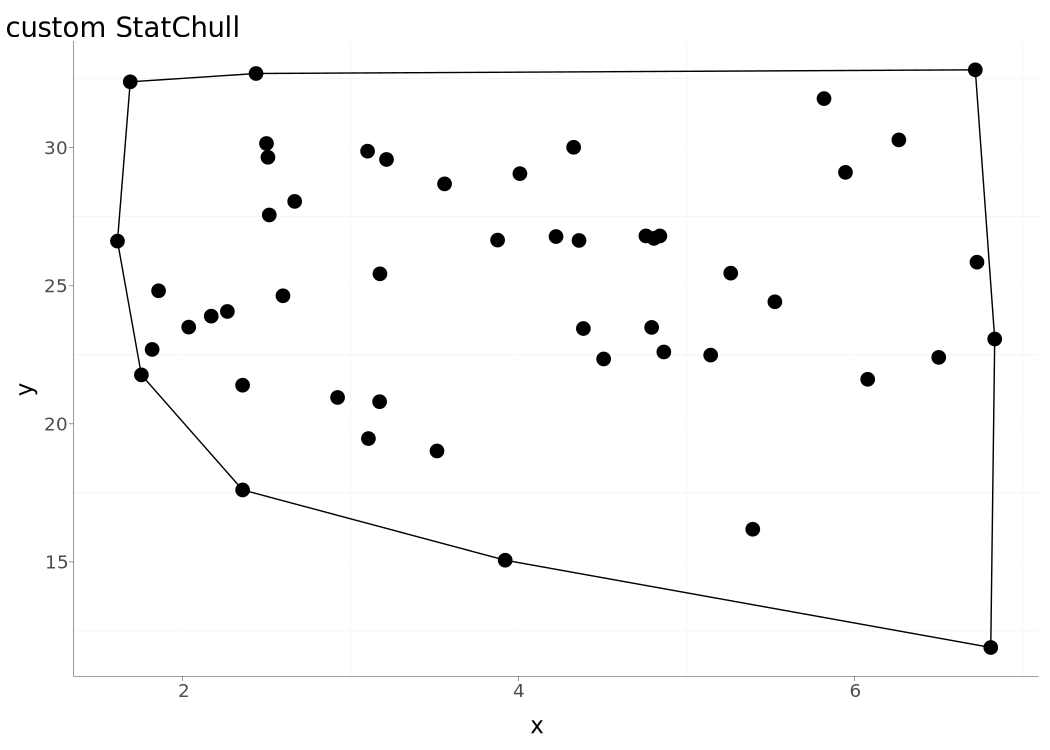

In [8]:
from ggplot2_py import ggplot, aes, geom_point, labs, theme_minimal

# Use StatChull via the layer wrapper
(
    ggplot(df, aes("x", "y"))
    + geom_point()
    + stat_chull(fill=None, colour="black")
    + labs(title="Convex hull via custom StatChull")
    + theme_minimal()
)

### Auto-registration via `__init_subclass__`

When you define `class StatChull(Stat)`, the `__init_subclass__` hook fires
and registers the class in `Stat._registry` under both the CamelCase key
(`"Chull"`) and the lowercase key (`"chull"`). This means:

- `layer(stat="chull", ...)` resolves to `StatChull` automatically
- No manual registration step is needed
- Extension packages get registered the moment their module is imported

In [9]:
# Verify auto-registration
print("Registry lookup 'Chull':", Stat._registry.get("Chull"))
print("Registry lookup 'chull':", Stat._registry.get("chull"))
print()

# Show a sample of all registered stats
unique_stats = sorted(set(
    k for k, v in Stat._registry.items() if k[0].isupper()
))
print(f"Total registered stat keys (CamelCase): {len(unique_stats)}")
print(f"First 10: {unique_stats[:10]}")

Registry lookup 'Chull': <ggproto class: StatChull>
Registry lookup 'chull': <ggproto class: StatChull>

Total registered stat keys (CamelCase): 32
First 10: ['Align', 'Bin', 'Bin2d', 'Bindot', 'Binhex', 'Boxplot', 'Chull', 'Connect', 'Contour', 'ContourFilled']


---

## Section 4: Creating a Custom Geom

Geoms render data as visual marks. Their lifecycle is:

```
setup_params(data, params) -> params
  setup_data(data, params) -> data
    draw_layer(data, params, layout, coord) -> list of grobs
      draw_panel(data, panel_params, coord, **params) -> grob  [per-panel]
        draw_group(data, panel_params, coord, **params) -> grob [per-group]
```

The `draw_panel` method receives **transformed** data (coordinates in [0, 1] range
after `coord.transform()`) and must return a **grid_py grob**.

### Key class attributes

| Attribute | Type | Purpose |
|-----------|------|---------|
| `required_aes` | `tuple[str, ...]` | Aesthetics that *must* be present |
| `non_missing_aes` | `tuple[str, ...]` | Aesthetics whose NAs trigger row removal |
| `optional_aes` | `tuple[str, ...]` | Extra accepted aesthetics |
| `default_aes` | `Mapping` | Default aesthetic values |
| `extra_params` | `tuple[str, ...]` | Extra non-aesthetic parameter names |
| `draw_key` | callable | Legend key drawing function |
| `rename_size` | `bool` | Whether to rename `size` to `linewidth` |

In [10]:
from ggplot2_py.geom import Geom
from ggplot2_py.aes import Mapping
from ggplot2_py.draw_key import draw_key_point


class GeomStar(Geom):
    """Draws star markers (pch=8) at each data point."""

    required_aes = ("x", "y")
    default_aes = Mapping(colour="black", fill="gold", size=3, alpha=1)
    draw_key = draw_key_point

    def draw_panel(self, data, panel_params, coord, **params):
        from grid_py import points_grob, Gpar, Unit

        data = coord.transform(data, panel_params)
        gp = Gpar(
            col=data["colour"].tolist(),
            fill=data.get("fill", "gold").tolist(),
        )
        return points_grob(
            x=data["x"].values,
            y=data["y"].values,
            pch=8,  # star marker
            size=Unit(data["size"].values * 2, "pt"),
            gp=gp,
        )


def geom_star(mapping=None, data=None, stat="identity", position="identity",
              na_rm=False, show_legend=None, inherit_aes=True, **kwargs):
    """Layer wrapper for GeomStar."""
    return Layer(
        geom=GeomStar, stat=stat, data=data, mapping=mapping,
        position=position, show_legend=show_legend,
        inherit_aes=inherit_aes, params={"na_rm": na_rm, **kwargs},
    )


print("GeomStar created successfully")
print(f"required_aes: {GeomStar.required_aes}")
print(f"default_aes: {GeomStar.default_aes}")

GeomStar created successfully
required_aes: ('x', 'y')
default_aes: aes(colour='black', fill='gold', size=3, alpha=1)


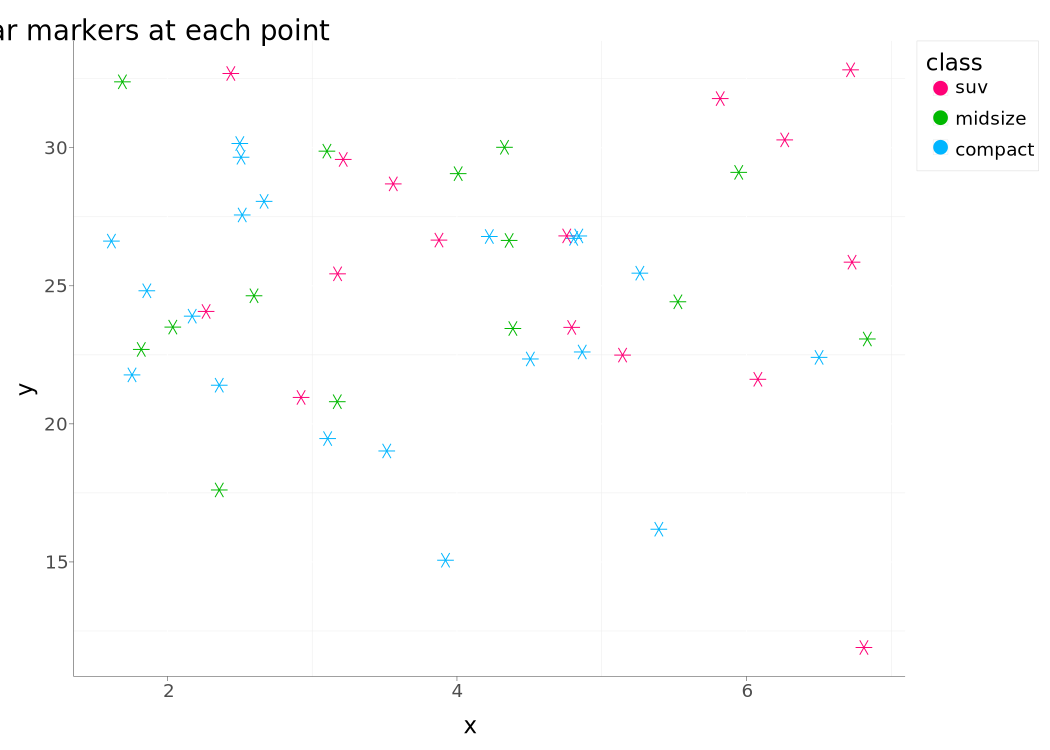

In [11]:
# Use GeomStar in a plot
(
    ggplot(df, aes("x", "y", colour="class"))
    + geom_star(size=4)
    + labs(title="Custom GeomStar: star markers at each point")
    + theme_minimal()
)

### Geom auto-registration

Just like Stats, Geom subclasses are auto-registered. `class GeomStar(Geom)` registers
under both `"Star"` and `"star"` keys in `Geom._registry`.

In [12]:
# Verify auto-registration
print("Registry lookup 'Star':", Geom._registry.get("Star"))
print("Registry lookup 'star':", Geom._registry.get("star"))
print()

# Show a sample of all registered geoms
unique_geoms = sorted(set(
    k for k, v in Geom._registry.items() if k[0].isupper()
))
print(f"Total registered geom keys (CamelCase): {len(unique_geoms)}")
print(f"First 10: {unique_geoms[:10]}")

Registry lookup 'Star': <ggproto class: GeomStar>
Registry lookup 'star': <ggproto class: GeomStar>

Total registered geom keys (CamelCase): 47
First 10: ['Abline', 'AnnotationMap', 'Area', 'Bar', 'Bin2d', 'Blank', 'Boxplot', 'Col', 'Contour', 'ContourFilled']


---

## Section 5: Protocol Contracts

ggplot2_py defines `@runtime_checkable` `typing.Protocol` classes for each GOG
component. These specify the **minimum interface** a class must satisfy to participate
in the pipeline --- without requiring inheritance from the base classes.

This enables:
- **Mypy / pyright** static checking: type errors at development time
- **Runtime `isinstance()` checks**: verify compliance without running a full plot
- **Duck typing**: any class that implements the required methods works

Available protocols: `GeomProtocol`, `StatProtocol`, `ScaleProtocol`,
`CoordProtocol`, `FacetProtocol`, `PositionProtocol`.

In [13]:
from ggplot2_py.protocols import GeomProtocol, StatProtocol

# Verify our custom classes satisfy the contracts (check on instances)
print("StatChull satisfies StatProtocol:", isinstance(StatChull(), StatProtocol))
print("GeomStar satisfies GeomProtocol:", isinstance(GeomStar(), GeomProtocol))

StatChull satisfies StatProtocol: True
GeomStar satisfies GeomProtocol: True


In [14]:
# A non-conforming class fails the check
class BadGeom:
    """Intentionally incomplete --- missing required_aes, draw_panel, etc."""
    pass

print("BadGeom satisfies GeomProtocol:", isinstance(BadGeom(), GeomProtocol))
print()
print("Protocol methods required by GeomProtocol:")
for name in ["required_aes", "default_aes", "draw_key", "setup_params",
             "setup_data", "draw_panel"]:
    print(f"  {name}: present on GeomStar = {hasattr(GeomStar, name)}, "
          f"present on BadGeom = {hasattr(BadGeom, name)}")

BadGeom satisfies GeomProtocol: False

Protocol methods required by GeomProtocol:
  required_aes: present on GeomStar = True, present on BadGeom = False
  default_aes: present on GeomStar = True, present on BadGeom = False
  draw_key: present on GeomStar = True, present on BadGeom = False
  setup_params: present on GeomStar = True, present on BadGeom = False
  setup_data: present on GeomStar = True, present on BadGeom = False
  draw_panel: present on GeomStar = True, present on BadGeom = False


---

## Section 6: `singledispatch` Extensibility

The `+` operator in ggplot2_py dispatches through `update_ggplot`, a
`functools.singledispatch` generic function. This means **any Python class** can
be made addable to a ggplot --- just register a handler.

Built-in registered types include `Layer`, `Scale`, `Coord`, `Facet`, `Mapping`,
`Theme`, `Labels`, and `list`. Extension authors can register their own types
to create domain-specific shorthand components.

In [15]:
from ggplot2_py import update_ggplot

# Show all currently registered types
print("Types registered with update_ggplot:")
for cls in sorted(update_ggplot.registry.keys(), key=lambda c: c.__name__):
    print(f"  {cls.__module__}.{cls.__name__}")

Types registered with update_ggplot:
  ggplot2_py.coord.Coord
  pandas.core.frame.DataFrame
  ggplot2_py.facet.Facet
  ggplot2_py.labels.Labels
  ggplot2_py.layer.Layer
  ggplot2_py.aes.Mapping
  builtins.NoneType
  ggplot2_py.scale.Scale
  ggplot2_py.theme.Theme
  builtins.list
  builtins.object


In [16]:
# Register a custom Watermark class
class Watermark:
    """Stamps a text watermark into the plot caption."""
    def __init__(self, text, alpha=0.3):
        self.text = text
        self.alpha = alpha


@update_ggplot.register(Watermark)
def _add_watermark(obj, plot, object_name=""):
    """When a Watermark is added via +, inject its text as a caption."""
    plot.labels["caption"] = f"[{obj.text}]"
    return plot


# Now use it with the + operator
p = ggplot(df, aes("x", "y")) + geom_point() + Watermark("DRAFT")
print("Caption:", p.labels.get("caption"))

Caption: [DRAFT]


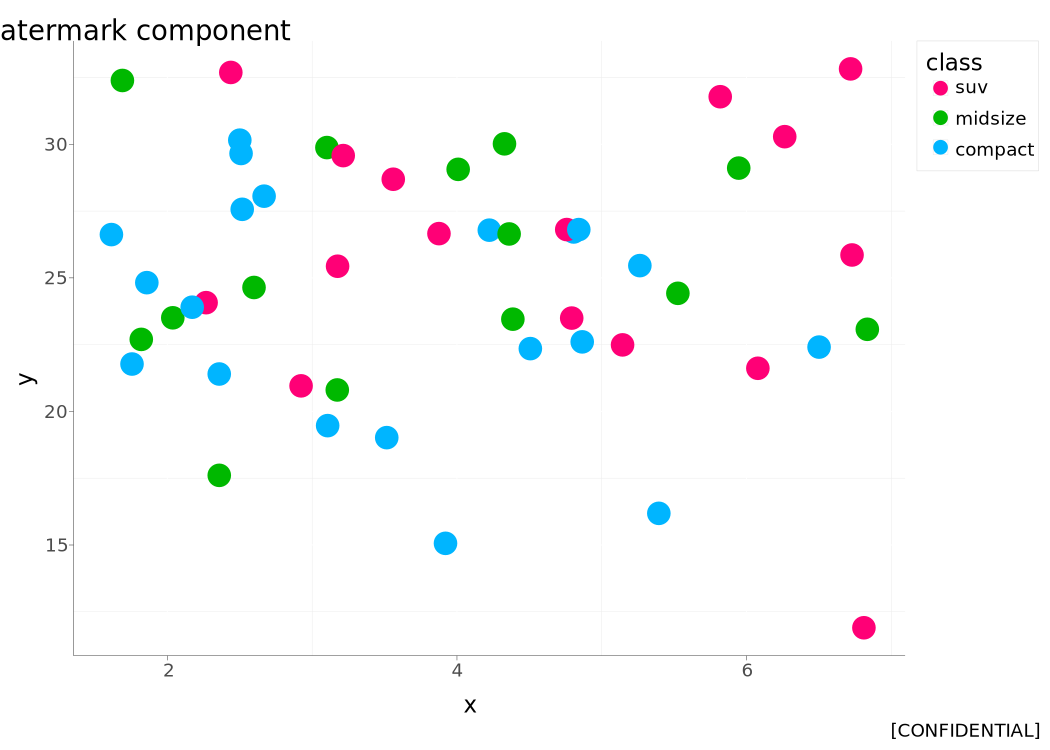

In [17]:
# Use the Watermark in a full plot
(
    ggplot(df, aes("x", "y", colour="class"))
    + geom_point(size=3)
    + Watermark("CONFIDENTIAL")
    + labs(title="Plot with custom Watermark component")
    + theme_minimal()
)

### When to use `singledispatch` registration

Use `@update_ggplot.register(MyClass)` when:

- Building an **extension package** that adds new plot components
- Creating a domain-specific shortcut (e.g. `+ BrandTheme()`)
- Injecting metadata (annotations, watermarks, data source labels)

For the `ggplot_build` pipeline, extension authors can similarly register custom
plot types via `ggplot_build.register` if they need to alter the build process.

---

## Section 7: Build Hooks

The `ggplot_build` pipeline has **16 named stages** (shown in Section 1). You can
register **before/after callbacks** on any stage to:

- Log/trace pipeline execution for debugging
- Modify per-layer data between stages
- Inject diagnostics without subclassing Stat/Geom

Hooks are registered via `plot.add_build_hook(timing, stage, fn)` where:

| Parameter | Values |
|-----------|--------|
| `timing` | `"before"` or `"after"` |
| `stage` | A `BuildStage` constant |
| `fn` | `fn(data: List[DataFrame], **ctx) -> List[DataFrame] or None` |

Return a new list to **replace** the data; return `None` to leave it unchanged.
The method returns `self`, so calls can be chained.

In [18]:
from ggplot2_py import ggplot_build, BuildStage

# Logging hook that traces the pipeline
trace = []

def trace_hook(data, **ctx):
    trace.append(f"layer count: {len(data)}, rows: {[len(d) for d in data]}")
    return data  # pass through unchanged

p = ggplot(df, aes("x", "y")) + geom_point()
p.add_build_hook("after", BuildStage.COMPUTE_STAT, trace_hook)

built = ggplot_build(p)
print("Trace after COMPUTE_STAT:")
for entry in trace:
    print(f"  {entry}")

Trace after COMPUTE_STAT:
  layer count: 1, rows: [50]


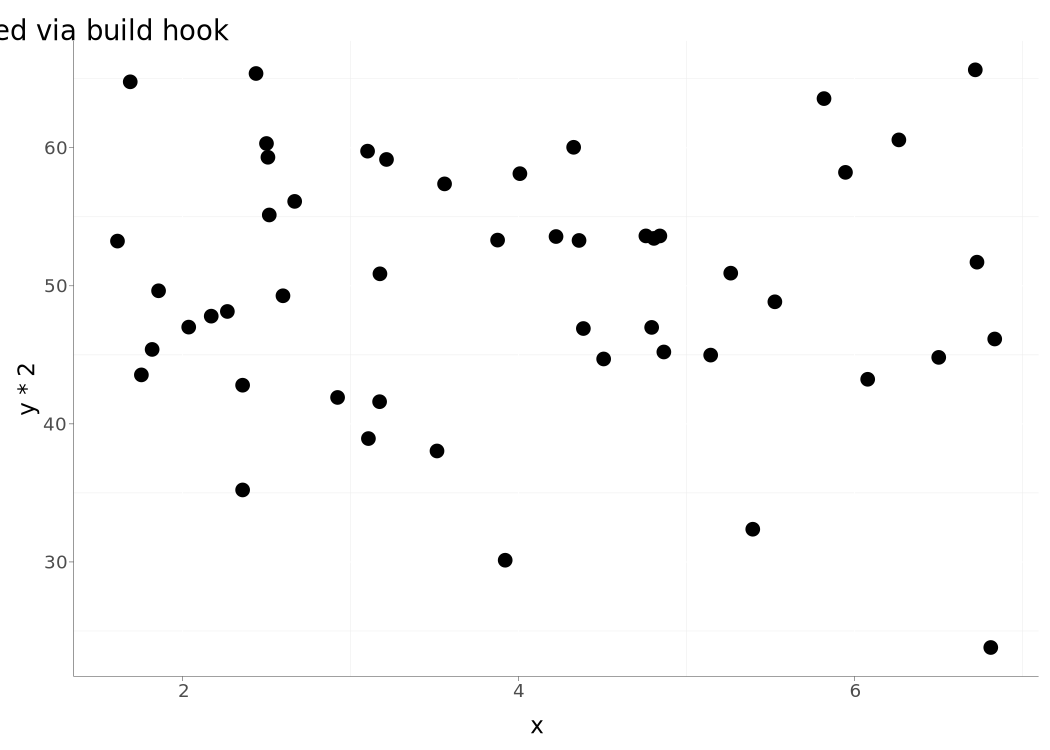

In [19]:
# Data-modifying hook: double all y values after aesthetics are computed
def scale_y(data, **ctx):
    """Double y values in every layer's DataFrame."""
    return [
        d.assign(y=d['y'] * 2) if 'y' in d.columns else d
        for d in data
    ]

p = (
    ggplot(df, aes(x='x', y='y'))
    + geom_point()
    + labs(title='y values doubled via build hook', y='y * 2')
    + theme_minimal()
)
p.add_build_hook("after", BuildStage.COMPUTE_AESTHETICS, scale_y)
p

In [20]:
# Diagnostic hook: track data shape evolution through the pipeline
diagnostics = []

def make_shape_hook(stage_name):
    """Factory: creates a hook that records per-layer shapes."""
    def hook(data, **ctx):
        shapes = [d.shape if hasattr(d, 'shape') else '(non-df)' for d in data]
        diagnostics.append((stage_name, shapes))
        return None  # return None = don't modify data
    return hook

p = ggplot(df, aes(x='x', y='y')) + geom_point() + theme_minimal()

for stage_name in [
    BuildStage.LAYER_DATA,
    BuildStage.COMPUTE_AESTHETICS,
    BuildStage.COMPUTE_STAT,
    BuildStage.COMPUTE_POSITION,
    BuildStage.FINISH_DATA,
]:
    p.add_build_hook("after", stage_name, make_shape_hook(stage_name))

built = ggplot_build(p)

print("Data shape evolution through pipeline:")
print(f"  {'Stage':<25} {'Layer 0 shape'}")
print(f"  {'-'*25} {'-'*15}")
for stage_name, shapes in diagnostics:
    print(f"  {stage_name:<25} {shapes[0]}")

Data shape evolution through pipeline:
  Stage                     Layer 0 shape
  ------------------------- ---------------
  layer_data                (50, 3)
  compute_aesthetics        (50, 4)
  compute_stat              (50, 4)
  compute_position          (50, 4)
  finish_data               (50, 10)


---

## Section 8: Callable `aes()` Expressions

In R, `aes()` uses non-standard evaluation (quosures) to capture expressions like
`aes(y = log(mpg))`. Python has no built-in NSE, so ggplot2_py accepts **callables**
(lambdas or functions) anywhere a string column name would go.

There are **three evaluation stages**, each with its own helper:

| Stage | Helper | When evaluated |
|-------|--------|---------------|
| Data stage | `aes(x=lambda d: ...)` | On raw layer data, before stat |
| After-stat | `after_stat(lambda d: ...)` | After `Stat.compute_*` adds columns |
| After-scale | `after_scale(lambda d: ...)` | After scale mapping resolves colours, etc. |

The `stage()` helper lets you specify different expressions for each stage.

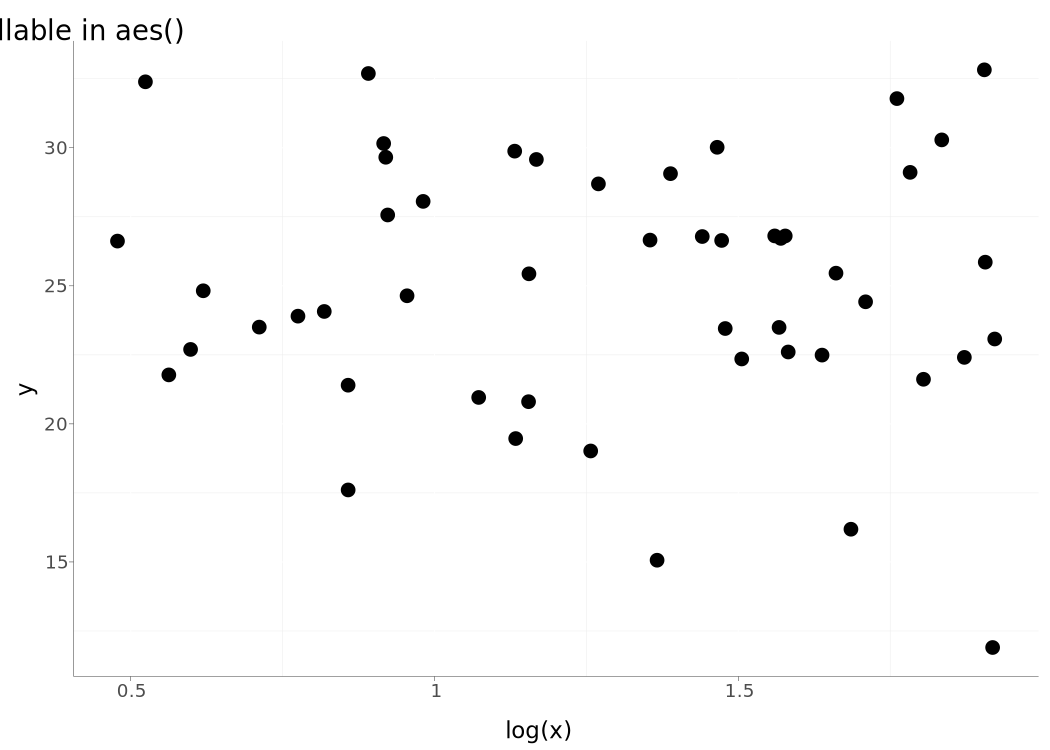

In [21]:
from ggplot2_py import after_stat, after_scale, stage, geom_histogram, geom_bar

# Stage 1: Transform data inline --- log-transform x without modifying the DataFrame
p1 = (
    ggplot(df, aes(x=lambda d: np.log(d['x']), y='y'))
    + geom_point()
    + labs(x='log(x)', title='Stage 1: callable in aes()')
    + theme_minimal()
)
p1

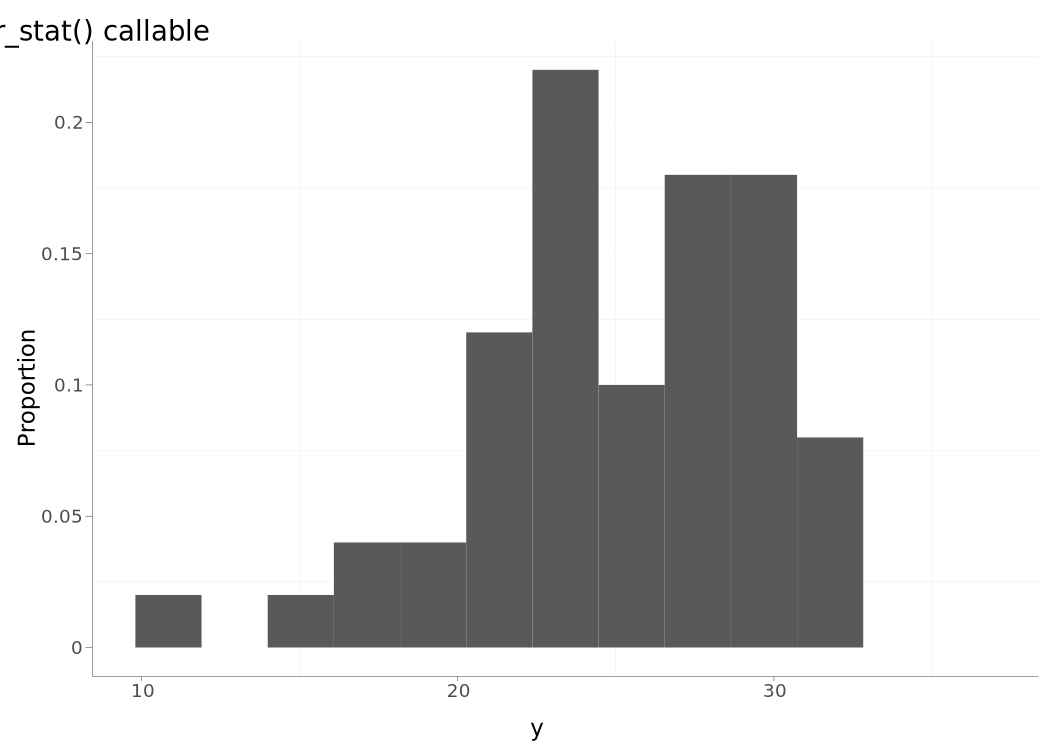

In [22]:
# Stage 2: Normalize stat output --- show proportions instead of counts
p2 = (
    ggplot(df, aes(x='y'))
    + geom_histogram(
        aes(y=after_stat(lambda d: d['count'] / d['count'].sum())),
        bins=12,
    )
    + labs(y='Proportion', title='Stage 2: after_stat() callable')
    + theme_minimal()
)
p2

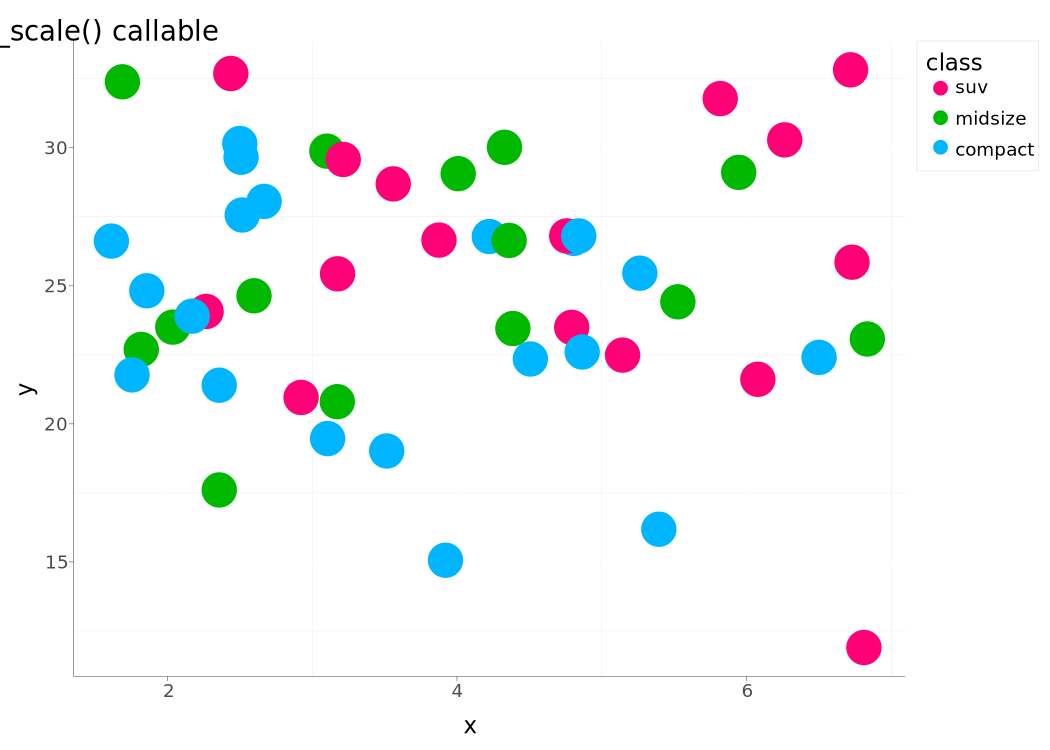

In [23]:
# Stage 3: Derive fill from the mapped colour aesthetic
p3 = (
    ggplot(df, aes(x='x', y='y', colour='class'))
    + geom_point(
        aes(fill=after_scale(lambda d: d['colour'])),
        shape=21, size=4, stroke=1,
    )
    + labs(title='Stage 3: after_scale() callable')
    + theme_minimal()
)
p3

In [24]:
# eval_aes_value() is the internal dispatcher that handles all three value types
from ggplot2_py.aes import eval_aes_value

sample = df.head(5)

# String -> column lookup
print("String lookup (y):")
print("  ", eval_aes_value('y', sample))

# Callable -> evaluated on the DataFrame
print("Callable (x * 10):")
print("  ", eval_aes_value(lambda d: d['x'] * 10, sample))

# Scalar -> returned as-is
print("Scalar (3.14):")
print("  ", eval_aes_value(3.14, sample))

String lookup (y):
   [28.6923329  25.85684141 24.42175859 23.49448152 17.60739005]
Callable (x * 10):
   [35.59970654 67.28928685 55.2596668  47.92621663 23.58102522]
Scalar (3.14):
   3.14


---

## Section 9: Context Manager --- Scoped Defaults

`ggplot_defaults()` is a **Python-exclusive** context manager with no R equivalent.
R has `theme_set()` for global state, but no scoped equivalent. This context manager
lets you set defaults (theme, coord, facet, mapping) that apply to all `ggplot()` calls
within the `with` block, without affecting code outside.

It uses `contextvars.ContextVar` under the hood, making it thread-safe.

In [25]:
from ggplot2_py import ggplot_defaults
from ggplot2_py.theme_defaults import theme_minimal

with ggplot_defaults(theme=theme_minimal()):
    p1 = ggplot(df, aes('x', 'y')) + geom_point()
    p2 = ggplot(df, aes('x', 'y')) + geom_point(colour='red')
    print("Inside context:")
    print(f"  p1 theme type: {type(p1.theme).__name__}")
    print(f"  p2 theme type: {type(p2.theme).__name__}")

# Outside: defaults are gone
p3 = ggplot(df, aes('x', 'y')) + geom_point()
print("\nOutside context:")
print(f"  p3 theme type: {type(p3.theme).__name__}")

Inside context:
  p1 theme type: Theme
  p2 theme type: Theme

Outside context:
  p3 theme type: dict


In [26]:
from ggplot2_py import coord_fixed

# You can set multiple defaults at once
with ggplot_defaults(theme=theme_minimal(), coord=coord_fixed()):
    p = (
        ggplot(df, aes('x', 'y'))
        + geom_point(size=2)
        + labs(title='Both theme_minimal and coord_fixed from context')
    )
    print(f"Coord type: {type(p.coordinates).__name__}")
    p

Coord type: CoordCartesian


---

## Section 10: Packaging Extensions

### Distributing as a pip package

To distribute your custom Stats/Geoms as a Python package:

**1. `pyproject.toml`:**

```toml
[project]
name = "ggplot2-stars"
version = "0.1.0"
dependencies = [
    "ggplot2_py>=4.0",
    "numpy>=1.24",
]
```

**2. Package structure:**

```
ggplot2_stars/
  __init__.py       # imports GeomStar, geom_star
  geom_star.py      # class GeomStar(Geom): ...
  stat_chull.py     # class StatChull(Stat): ...
```

**3. Auto-registration on import:**

Because `Geom.__init_subclass__` and `Stat.__init_subclass__` auto-register
subclasses, your extension classes are registered the moment the module is
imported. Users just need:

```python
import ggplot2_stars  # registers GeomStar, StatChull
from ggplot2_py import ggplot, aes
from ggplot2_stars import geom_star, stat_chull
```

**Future:** entry-point-based plugin discovery (PEP 621 `[project.entry-points]`)
is planned, so extensions can be discovered automatically without explicit import.

### Summary of all extension points

| Extension point | Mechanism | R equivalent | Python-exclusive? |
|----------------|-----------|-------------|-------------------|
| Custom Stat | Subclass `Stat`, override `compute_group` | `ggproto("StatFoo", Stat, ...)` | No |
| Custom Geom | Subclass `Geom`, override `draw_panel` | `ggproto("GeomFoo", Geom, ...)` | No |
| Custom Scale | Subclass `ScaleContinuous`/`ScaleDiscrete` | `ggproto("ScaleFoo", Scale, ...)` | No |
| Custom Coord | Subclass `Coord` | `ggproto("CoordFoo", Coord, ...)` | No |
| Custom Facet | Subclass `Facet` | `ggproto("FacetFoo", Facet, ...)` | No |
| Custom Position | Subclass `Position` | `ggproto("PositionFoo", Position, ...)` | No |
| Auto-registration | `__init_subclass__` hook | None (manual) | Yes |
| Protocol contracts | `typing.Protocol` + `isinstance()` | None | Yes |
| `+` operator dispatch | `@update_ggplot.register(MyClass)` | `ggplot_add.MyClass` (S3) | No (mechanism differs) |
| Build hooks | `plot.add_build_hook(timing, stage, fn)` | None | Yes |
| Callable aes | `aes(x=lambda d: ...)` | `aes(x = expr)` (NSE) | Yes (mechanism differs) |
| Scoped defaults | `ggplot_defaults(theme=...)` | `theme_set()` (global only) | Yes |
| `after_stat` / `after_scale` | `after_stat(fn)`, `after_scale(fn)` | `after_stat(expr)` | No (mechanism differs) |
| `stage()` multi-stage | `stage(start=..., after_stat=..., after_scale=...)` | `stage(start, after_stat, after_scale)` | No |